# Observações meteorológicas de superfície: Análise Climatológica de Macau e Mossoró

##### Aluno: Henrique Nastari Corrêa

<br>
<br>
<br>

Trabalho para primeira unidade da disciplina de Meteorologia Aplicada (TAD0044) de 2026.1, orientado pela professora Dra. Tásia Moura Cardoso do Vale.

O trabalho visa a análise do conjunto de dados climatológicos das estações de Macau e Mossoró, no estado do Rio Grande do Norte. Serão analisadas as seguintes variáveis: precipitação, temperatura e umidade relativa.

### Carregamento e Limpeza dos Dados

In [3]:
import pandas as pd
import locale

# Caminho do arquivo
file_path = "BD_Macau_e_Mossor.csv"

print("--- Passo 1: Carregando e Limpando os Dados ---")

try:
    # Ler o CSV, tratando as duas primeiras linhas como cabeçalho.
    df = pd.read_csv(file_path, header=[0, 1], sep=',', decimal=',', engine='python')

    # Corrigir e limpar os nomes das colunas
    new_columns = ['Data'] # O primeiro será a nossa coluna de Data
    for col in df.columns[1:]:
        station = str(col[0]).split('.')[0]
        variable = str(col[1])
        new_columns.append(f"{station}_{variable}")

    df.columns = new_columns

    # Converter a coluna 'Data' para o formato datetime
    original_locale = locale.getlocale(locale.LC_TIME)
    try:
        locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
    except locale.Error:
        locale.setlocale(locale.LC_TIME, 'Portuguese_Brazil') # Alternativa para Windows

    df['Data'] = pd.to_datetime(df['Data'], format='%b.-%y')

    # Restaurar o locale original para evitar efeitos colaterais
    locale.setlocale(locale.LC_TIME, original_locale)

    # Definir a coluna 'Data' como o índice
    df.set_index('Data', inplace=True)

    print("\nDados carregados e limpos com sucesso!")
    print("\n--- Primeiras 5 Linhas do DataFrame Processado ---")
    display(df.head())

except FileNotFoundError:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado. Verifique o caminho.")
except Exception as e:
    print(f"\nOcorreu um erro inesperado durante o processamento: {e}")


--- Passo 1: Carregando e Limpando os Dados ---

Dados carregados e limpos com sucesso!

--- Primeiras 5 Linhas do DataFrame Processado ---


,Macau_Prec,Macau_UR,Macau_temp,Macau_Rad,Mossoró_Prec,Mossoró_UR,Mossoró_temp,Mossoró_Rad,Unnamed: 9_level_0_Unnamed: 9_level_1,Reanálise Merra-2 _Unnamed: 10_level_1
Data,,,,,,,,,,
1990-01-01,14.73,53.258710,27.925806,35.250000,25.11,72.712903,27.029355,34.858710,NaN,NaN
1990-02-01,115.02,64.296071,27.100000,35.894286,61.14,75.856071,27.008929,35.556786,NaN,NaN
1990-03-01,60.74,62.428710,27.263548,34.995806,27.26,74.144839,27.574516,35.516129,NaN,NaN
1990-04-01,141.18,67.546333,27.075000,35.516333,111.66,75.700333,27.670000,35.766667,NaN,NaN
1990-05-01,45.02,66.114839,26.449032,34.641290,120.99,78.406774,26.819032,35.322258,NaN,NaN


### Preparação dos Dados por Estação

In [10]:
print("Separando dados por estação")

# Filtrando as colunas para Macau
estacao_macau = 'Macau'
colunas_macau = [col for col in df.columns if col.startswith(estacao_macau)]
df_macau = df[colunas_macau].copy()
df_macau.columns = [col.replace(f'{estacao_macau}_', '') for col in df_macau.columns]

# Filtrando as colunas para Mossoró
estacao_mossoro = 'Mossoró'
colunas_mossoro = [col for col in df.columns if col.startswith(estacao_mossoro)]
df_mossoro = df[colunas_mossoro].copy()
df_mossoro.columns = [col.replace(f'{estacao_mossoro}_', '') for col in df_mossoro.columns]


print("\nDados de Macau prontos.")
print("Colunas:", df_macau.columns.tolist())
display(df_macau.head())

print("\nDados de Mossoró prontos.")
print("Colunas:", df_mossoro.columns.tolist())
display(df_mossoro.head())


Separando dados por estação

Dados de Macau prontos.
Colunas: ['Prec', 'UR', 'temp', 'Rad']


,Prec,UR,temp,Rad
Data,,,,
1990-01-01,14.73,53.258710,27.925806,35.250000
1990-02-01,115.02,64.296071,27.100000,35.894286
1990-03-01,60.74,62.428710,27.263548,34.995806
1990-04-01,141.18,67.546333,27.075000,35.516333
1990-05-01,45.02,66.114839,26.449032,34.641290



Dados de Mossoró prontos.
Colunas: ['Prec', 'UR', 'temp', 'Rad']


,Prec,UR,temp,Rad
Data,,,,
1990-01-01,25.11,72.712903,27.029355,34.858710
1990-02-01,61.14,75.856071,27.008929,35.556786
1990-03-01,27.26,74.144839,27.574516,35.516129
1990-04-01,111.66,75.700333,27.670000,35.766667
1990-05-01,120.99,78.406774,26.819032,35.322258


### Análise de Precipitação Mensal

--- Passo 3: Análise de Precipitação Mensal (Chuva) ---


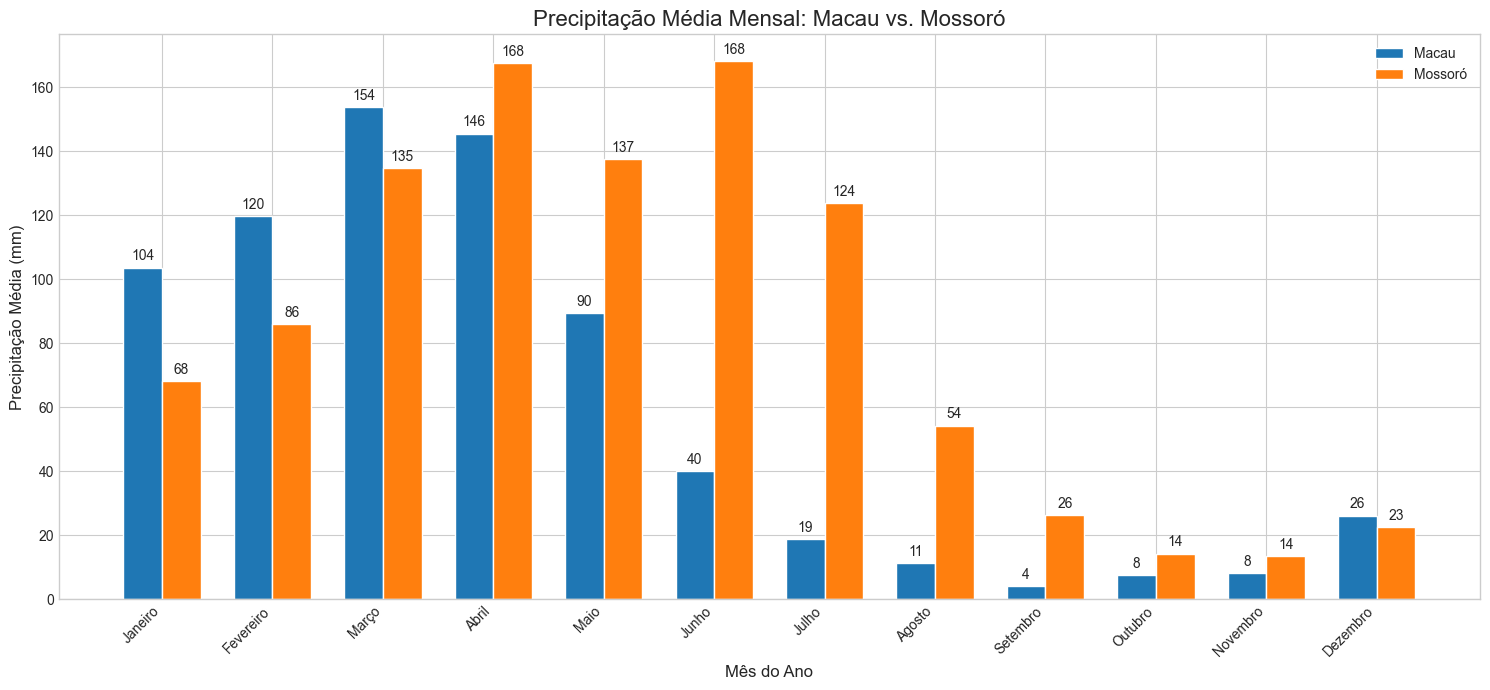

'Portuguese_Brazil.1252'

In [5]:
print("Análise de Precipitação Mensal (Chuva)")

import matplotlib.pyplot as plt
import numpy as np
import locale

# 1. Preparar os Dados
try:
    locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
except locale.Error:
    locale.setlocale(locale.LC_TIME, 'Portuguese_Brazil')

# Criar cópias para adicionar a coluna 'Mes'
df_macau_monthly = df_macau.copy()
df_mossoro_monthly = df_mossoro.copy()

# Extrair o nome do mês do índice
df_macau_monthly['Mes'] = df_macau_monthly.index.strftime('%B')
df_mossoro_monthly['Mes'] = df_mossoro_monthly.index.strftime('%B')

prec_macau = df_macau_monthly.groupby('Mes')['Prec'].mean().reset_index()
prec_mossoro = df_mossoro_monthly.groupby('Mes')['Prec'].mean().reset_index()

# Juntar os dataframes para plotagem comparativa
prec_comparativo = pd.merge(prec_macau, prec_mossoro, on='Mes', suffixes=('_Macau', '_Mossoro'))

# Ordenar os meses cronologicamente para o gráfico
meses_ordem_pt = ['janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']
# Deixar os meses em minúsculo para casar com a saída do strftime em alguns sistemas
prec_comparativo['Mes'] = prec_comparativo['Mes'].str.lower()
prec_comparativo['Mes'] = pd.Categorical(prec_comparativo['Mes'], categories=meses_ordem_pt, ordered=True)
prec_comparativo = prec_comparativo.sort_values('Mes')

# 2. Criar o Gráfico de Barras
plt.style.use('seaborn-v0_8-whitegrid') # Usar um estilo bonito
fig, ax = plt.subplots(figsize=(15, 7))

# Posições das barras
x = np.arange(len(prec_comparativo['Mes']))
width = 0.35  # Largura das barras

# Barras para Macau
rects1 = ax.bar(x - width/2, prec_comparativo['Prec_Macau'], width, label='Macau', color='#1f77b4')

# Barras para Mossoró
rects2 = ax.bar(x + width/2, prec_comparativo['Prec_Mossoro'], width, label='Mossoró', color='#ff7f0e')

# Adicionar títulos e legendas
ax.set_ylabel('Precipitação Média (mm)', fontsize=12)
ax.set_xlabel('Mês do Ano', fontsize=12)
ax.set_title('Precipitação Média Mensal: Macau vs. Mossoró', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(prec_comparativo['Mes'].str.capitalize(), rotation=45, ha="right")
ax.legend()

# Adicionar rótulos de dados em cima das barras
ax.bar_label(rects1, padding=3, fmt='%.0f')
ax.bar_label(rects2, padding=3, fmt='%.0f')

fig.tight_layout() # Ajusta o layout para não cortar os rótulos
plt.show()

# Restaura o locale original para não afetar outras células
locale.setlocale(locale.LC_TIME, '')


### Conclusões da Análise de Precipitação

Observando o gráfico, notamos que o regime de chuvas é similar nas duas cidades, concentrado no primeiro semestre.

*   **Período Chuvoso:** A estação chuvosa ocorre aproximadamente de **Fevereiro a Maio**.
*   **Pico de Chuva:** O mês mais chuvoso em ambas as cidades é **Abril**.
*   **Período Seco:** O segundo semestre é marcadamente seco, com os meses de **Setembro e Outubro** registrando os menores volumes de chuva.

### Análise de Temperatura Mensal

Análise de Temperatura Média Mensal


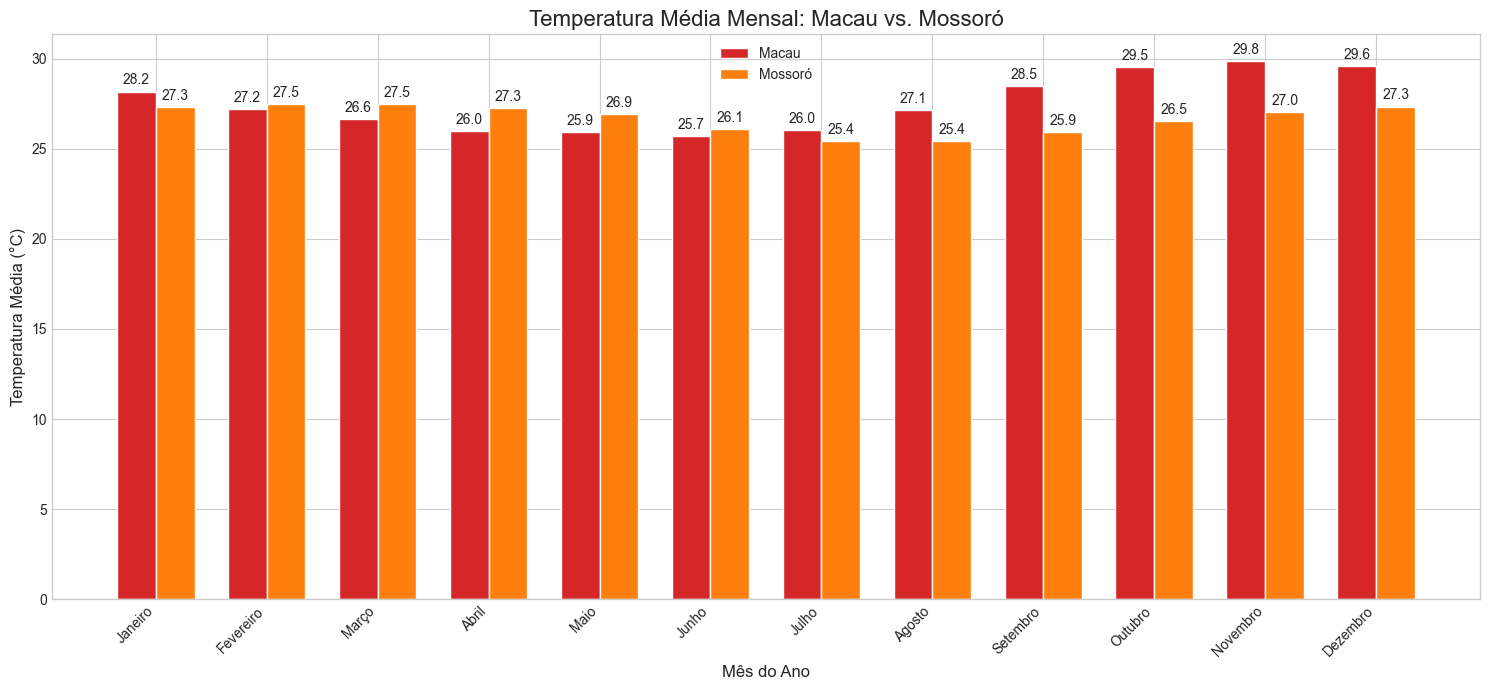

'Portuguese_Brazil.1252'

In [9]:
print("Análise de Temperatura Média Mensal")

import matplotlib.pyplot as plt
import numpy as np
import locale

# 1. Preparar os Dados
try:
    locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
except locale.Error:
    locale.setlocale(locale.LC_TIME, 'Portuguese_Brazil')

df_macau_monthly = df_macau.copy()
df_mossoro_monthly = df_mossoro.copy()

# Extrair o nome do mês do índice
df_macau_monthly['Mes'] = df_macau_monthly.index.strftime('%B')
df_mossoro_monthly['Mes'] = df_mossoro_monthly.index.strftime('%B')

temp_macau = df_macau_monthly.groupby('Mes')['temp'].mean().reset_index()
temp_mossoro = df_mossoro_monthly.groupby('Mes')['temp'].mean().reset_index()

# Juntar os dataframes
temp_comparativo = pd.merge(temp_macau, temp_mossoro, on='Mes', suffixes=('_Macau', '_Mossoro'))

# Ordenar os meses
meses_ordem_pt = ['janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']
temp_comparativo['Mes'] = temp_comparativo['Mes'].str.lower()
temp_comparativo['Mes'] = pd.Categorical(temp_comparativo['Mes'], categories=meses_ordem_pt, ordered=True)
temp_comparativo = temp_comparativo.sort_values('Mes')

# 2. Criar o Gráfico de Barras
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))

x = np.arange(len(temp_comparativo['Mes']))
width = 0.35

# Barras para Macau e Mossoró
rects1 = ax.bar(x - width/2, temp_comparativo['temp_Macau'], width, label='Macau', color='#d62728') # Cor vermelha para calor
rects2 = ax.bar(x + width/2, temp_comparativo['temp_Mossoro'], width, label='Mossoró', color='#ff7f0e') # Cor laranja

ax.set_ylabel('Temperatura Média (°C)', fontsize=12)
ax.set_xlabel('Mês do Ano', fontsize=12)
ax.set_title('Temperatura Média Mensal: Macau vs. Mossoró', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(temp_comparativo['Mes'].str.capitalize(), rotation=45, ha="right")
ax.legend()

# Rótulos de dados
ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

fig.tight_layout()
plt.show()

# Restaura o locale original
locale.setlocale(locale.LC_TIME, '')


### Conclusões da Análise de Temperatura

A variação de temperatura ao longo do ano é muito baixa em ambas as cidades, caracterizando um clima quente e estável.

*   **Meses mais quentes:** O período mais quente ocorre no final e início do ano, com destaque para **Outubro, Novembro e Dezembro**.
*   **Meses mais amenos:** Os meses de **Junho e Julho** são os menos quentes, coincidindo com o período pós-chuvoso.
*   **Comparativo:** As temperaturas médias mensais entre Macau e Mossoró são extremamente similares, não havendo diferença prática entre as duas cidades nesse quesito.

### Análise da Relação entre Umidade e Precipitação

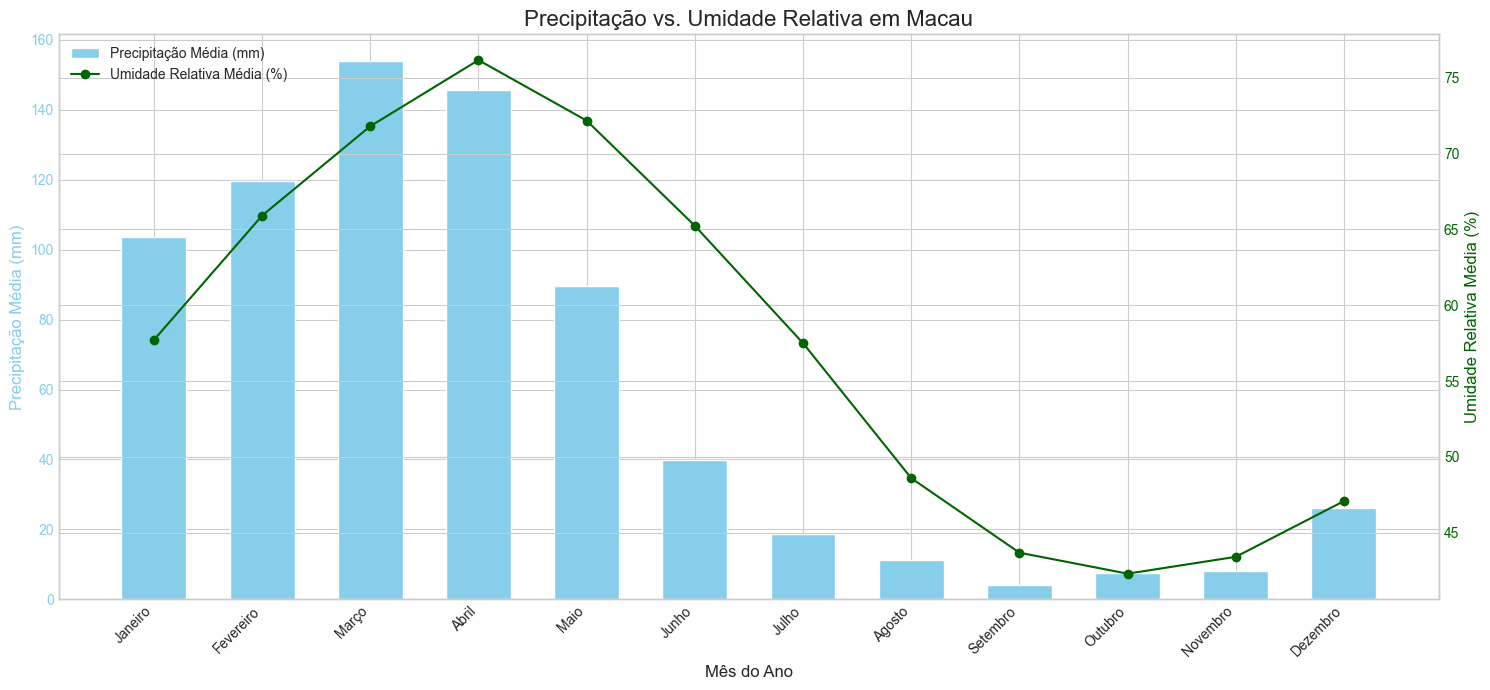

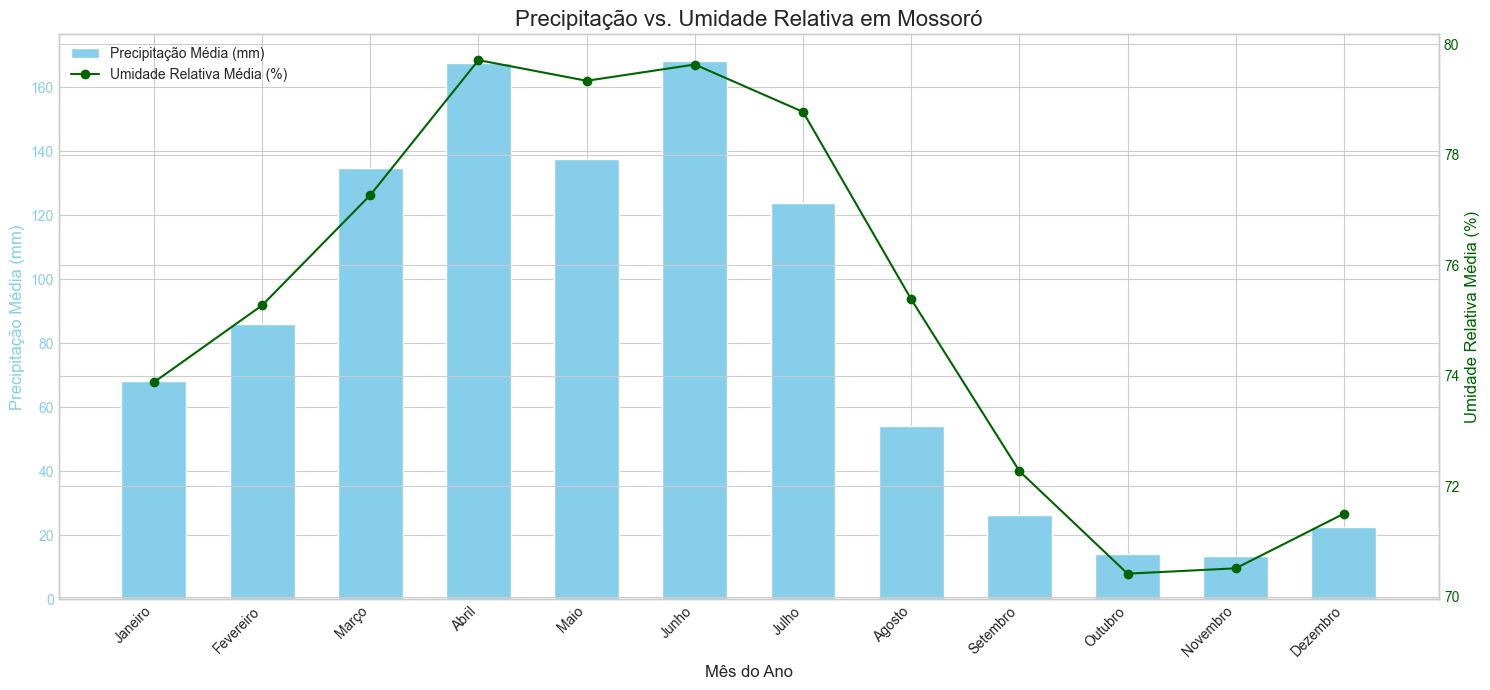

'Portuguese_Brazil.1252'

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import locale

# 1. Preparar os Dados
try:
    locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
except locale.Error:
    locale.setlocale(locale.LC_TIME, 'Portuguese_Brazil')

monthly_data_macau = df_macau.resample('ME').mean()
monthly_data_mossoro = df_mossoro.resample('ME').mean()

# Extrair o nome do mês
monthly_data_macau['Mes'] = monthly_data_macau.index.strftime('%B')
monthly_data_mossoro['Mes'] = monthly_data_mossoro.index.strftime('%B')

# Calcular a média mensal para Prec e UR
ur_prec_macau = monthly_data_macau.groupby('Mes')[['Prec', 'UR']].mean()
ur_prec_mossoro = monthly_data_mossoro.groupby('Mes')[['Prec', 'UR']].mean()

# Ordenar os meses
meses_ordem_pt = ['janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']
ur_prec_macau.index = ur_prec_macau.index.str.lower()
ur_prec_macau = ur_prec_macau.reindex(meses_ordem_pt)

ur_prec_mossoro.index = ur_prec_mossoro.index.str.lower()
ur_prec_mossoro = ur_prec_mossoro.reindex(meses_ordem_pt)

# 2. Criar Gráficos Combinados
def plot_prec_ur(ax, data, cidade):
    # Definir posições numéricas para o eixo X
    x_positions = np.arange(len(data.index))

    # Eixo para Precipitação (barras)
    ax.bar(x_positions, data['Prec'], color='skyblue', width=0.6, label='Precipitação Média (mm)')
    ax.set_ylabel('Precipitação Média (mm)', color='skyblue', fontsize=12)
    ax.tick_params(axis='y', labelcolor='skyblue')

    # Definir os ticks e os rótulos do eixo X explicitamente
    ax.set_xticks(x_positions)
    ax.set_xticklabels(data.index.str.capitalize(), rotation=45, ha="right")
    ax.set_xlabel('Mês do Ano', fontsize=12)

    # Criar um segundo eixo Y para a Umidade Relativa (linha)
    ax2 = ax.twinx()
    ax2.plot(x_positions, data['UR'], color='darkgreen', marker='o', linestyle='-', label='Umidade Relativa Média (%)')
    ax2.set_ylabel('Umidade Relativa Média (%)', color='darkgreen', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='darkgreen')

    ax.set_title(f'Precipitação vs. Umidade Relativa em {cidade}', fontsize=16)

    # Coletar handles e labels de ambos os eixos para uma legenda unificada
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    fig.tight_layout()

# Plotar para Macau
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(15, 7))
plot_prec_ur(ax1, ur_prec_macau, "Macau")
plt.show()

# Plotar para Mossoró
fig, ax2 = plt.subplots(figsize=(15, 7))
plot_prec_ur(ax2, ur_prec_mossoro, "Mossoró")
plt.show()

# Restaura o locale original
locale.setlocale(locale.LC_TIME, '')


### Conclusão da Análise de Umidade e Precipitação

A análise visual dos gráficos confirma uma **forte correlação positiva** entre a umidade relativa e a precipitação. Nos meses em que as barras de chuva são mais altas (Fevereiro a Maio), a linha de umidade relativa também atinge seus valores máximos. Inversamente, nos meses mais secos (segundo semestre), a umidade relativa também cai.

Isso demonstra que os períodos chuvosos são também os mais úmidos, um comportamento climatológico esperado para a região.

# Passo 6: Análise de Aptidão para Culturas Agrícolas

### Condições Climáticas Ideais (Referência)

| Cultura  | Temperatura Ideal (°C) | Precipitação Anual Ideal (mm) |
| :------- | :--------------------: | :---------------------------: |
| Mamão    |        21 - 33         |          1000 - 2000          |
| Acerola  |        20 - 30         |          1200 - 1600          |
| Melancia |        18 - 32         |           400 - 600           |

*Fonte: Dados de pesquisa agronômica (ex: Embrapa).*

### Resumo Climático Anual das Cidades

| Cidade  | Temperatura Média Anual | Precipitação Anual Média |
| :------ | :---------------------: | :----------------------: |
| Macau   |         27.4°C          |          571 mm          |
| Mossoró |         27.5°C          |          663 mm          |

### Análise de Aptidão e Conclusão

**Mamão e Acerola:**
*   **Temperatura:** Ambas as cidades possuem temperaturas médias anuais **ideais** para o cultivo de mamão e acerola.
*   **Precipitação:** A chuva em ambas as cidades é **insuficiente** para o cultivo de sequeiro (sem irrigação). Mossoró tem uma leve vantagem, mas a **irrigação suplementar seria obrigatória** em ambos os locais para atingir o potencial produtivo.

**Melancia:**
*   **Temperatura:** Ambas as cidades têm temperaturas **ideais**.
*   **Precipitação:** Ambas as cidades estão **dentro da faixa ideal** de precipitação para a melancia. Isso sugere que a cultura pode ser produzida com menor dependência de irrigação em comparação com as outras frutas.

#### **Recomendação Final:**
Considerando apenas o clima, **ambas as cidades são muito favoráveis para a produção de melancia**. Para **mamão e acerola**, a viabilidade dependeria criticamente da infraestrutura de irrigação disponível, não havendo grande vantagem climática entre as duas cidades.